In [1]:
import os
os.chdir('/workspace/dd2b00ec-36b8-499e-8e7d-d1f2eb8c378f')
print(os.listdir('.'))


['peaks_features_F1_F12_normalized_full_with_spectral_complex.csv', '.kernel_llm_logs_1.txt', 'memory', '.prompts', '.config', ' v6 — Binding Context Document.pdf']


In [2]:
import pandas as pd
df = pd.read_csv('peaks_features_F1_F12_normalized_full_with_spectral_complex.csv')
print(df.shape)
print(df.columns.tolist())
print(df[['function_id','GRH','pc1_complex','H_complex']].drop_duplicates() if 'function_id' in df.columns else df.head())


(2200, 35)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7', 'pc1_complex', 'H_complex', 'pc1_mag', 'H_mag']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... log_abs_S6_norm log_abs_S6 abs_S6 log_abs_S7_norm \
0 1.0 ... -0.523985 -1.268552 0.281238 -2.281314 
1 1.0 ... -0.695810 -1.682548 0.185900 -2.191351 
2 1.0 ... -0.701922 -1.711686 0.180561 -2.438321 
3 1.0 ... -0.396795 -0.968595 0.379616 -2.24

In [3]:
summary = df.groupby(['function','name','GRH']).agg(pc1_complex=('pc1_complex','first'),
 H_complex=('H_complex','first'),
 t_min=('t','min'),
 t_max=('t','max')).reset_index()
print(summary.to_string())


 function name GRH pc1_complex H_complex t_min t_max
0 F1 zeta True 0.964841 0.090979 22299.1 99937.9
1 F10 11.2.a.a True 0.952850 0.105545 13058.8 99962.1
2 F11 Sym^2 Delta True 0.954236 0.103464 10411.7 99345.6
3 F12 L(chi3)+c*L(chi5) False 0.903412 0.188774 14118.3 99888.4
4 F2 L(chi5_quartic) True 0.936709 0.132575 17859.9 99586.9
5 F4 L_DH False 0.903511 0.206217 17859.8 99972.8
6 F5m L_DH(-0.05) False 0.906186 0.201827 17859.8 99972.8
7 F5p L_DH(+0.05) False 0.902737 0.208371 17859.8 99972.8
8 F6 Liouville True 0.937852 0.133036 15387.4 99716.8
9 F7 Mobius True 0.937539 0.132538 14735.5 99923.7
10 F9 Delta True 0.956380 0.102094 14990.7 99515.4


In [4]:

# Plan:
# 1. Generate coefficients for L(s,Δ) (Ramanujan tau) for n<=N=10^6 using the recurrences.
# We'll use tau via cypari2 if available. Otherwise via Ramanujan tau formulas (mfcoefs).
# 2. Generate χ_5 quartic character mod 5. Note: F2 in CSV is named L(chi5_quartic).
# The hypothesis says F15 = L(s, Δ⊗χ_5). χ_5 here is the primitive Dirichlet quartic
# character mod 5 (one of the two non-real ones). Twist coefficients: a(n)*χ_5(n).
# 3. χ_3: primitive Dirichlet character mod 3. χ_3(1)=1, χ_3(2)=-1, χ_3(3k)=0.
# 4. Build F16(c)(n) = a_F15(n) + c * χ_3(n).
# 5. Compute |F16(c)(1/2+it)| via partial sum (truncated Dirichlet series approximation)
# over t in [10^4, 2*10^4]. Locate top 200 peaks. Compute S_k(t) = Σ_{ω(n)=k} a(n) n^{-1/2-it}
# for k=0..7. Compute M_jk = mean over peaks of Re(S_j conj(S_k)).
# 6. Compute pc1_complex = lambda_max / trace(M); H_complex = entropy of normalized eigenvalues.

# Let's first try to install/import cypari2 / sympy / numba.
import importlib, subprocess, sys

for pkg in ['cypari2','numba','sympy']:
 try:
 importlib.import_module(pkg)
 print(pkg, 'ok')
 except ImportError:
 print(pkg, 'missing - installing')
 subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


cypari2 missing - installing


numba ok


sympy ok


In [5]:

# Try cypari2 directly
try:
 import cypari2
 pari = cypari2.Pari()
 print('cypari2 OK, version:', pari.version())
except Exception as e:
 print('cypari2 failed:', e)


cypari2 OK, version: (2, 17, 2)


In [6]:

# Great. Now compute Ramanujan tau coefficients up to N=10^6 using PARI/GP.
import cypari2, numpy as np, time
pari = cypari2.Pari()
pari.allocatemem(1<<31) # 2 GB stack
print('stack allocated')
N = 10**6
t0 = time.time()
# Approach: build modular form Delta = mfDelta. Then mfcoefs.
mf = pari("mfinit([1,12], 1)")
print('mfinit done', time.time()-t0)
delta = pari("mfDelta()")
print('delta defined', time.time()-t0)


PARI stack size set to 2147483648 bytes, maximum size set to 2147483648
stack allocated
mfinit done 0.03904867172241211
delta defined 0.0394439697265625


In [7]:

# Get the Ramanujan tau coefficients for n=1..N
t0 = time.time()
coefs = pari.mfcoefs(delta, N)
print('mfcoefs time:', time.time()-t0, 'len(coefs)=', len(coefs))
# Convert to numpy. coefs[0] corresponds to n=0; mfcoefs returns a vector of length N+1.
print(coefs[0:6])


mfcoefs time: 4.595017433166504 len(coefs)= 1000001
[0, 1, -24, 252, -1472, 4830]


In [8]:

# Convert to numpy int64 array (tau(n) bounded by Deligne 2 n^{11/2}, large numbers!).
# Note: |tau(n)| <= d(n) n^{11/2}. For n=10^6, ~ 10^33 - overflows int64!
# So we need to normalize Δ to its "analytic" form: a_n = tau(n)/n^{11/2}.
# This is the Selberg-class normalized form. The Hecke L-function L(s,Δ) has coefficients
# a_n = tau(n)/n^{11/2}.
# Let's create a_n_delta = tau(n) / n^{(k-1)/2} = tau(n)/n^{11/2}.
t0 = time.time()
import numpy as np
# Convert pari vec elementwise via Python int -> use python conversion
# Use pari to compute normalized: but easier: copy as Python ints.
# coefs is a Gen vector -> can iterate.

# Use the fact that mfcoefs returns a t_VEC; we can call Python int(coefs[i])
# That may be slow for 10^6. Better: pari -> string -> parse? Or use lift.
# Actually cypari2 supports __int__ on Gens.

tau = np.zeros(N+1, dtype=object) # object for python ints (arbitrary precision)
# This may be slow. Let's try.
# Alternative: use pari("Vec(...)") or evaluate to_python. cypari2 has python().
t0 = time.time()
tau_list = coefs.python() # convert whole vector to python list
print('python() conversion time:', time.time()-t0, 'type:', type(tau_list), 'len:', len(tau_list))


python() conversion time: 0.12871646881103516 type: <class 'list'> len: 1000001


In [9]:

# Great. tau_list is a Python list of arbitrary-precision ints.
# Now normalize a_n = tau(n) / n^{11/2}.
# To avoid overflow, we use float64 division at the end.
# tau(n) can be huge but float division will lose precision for n ~ small but not catastrophically since we'll compute a_n as a float.
# Actually we need numerical a_n with reasonable precision.
import math
t0 = time.time()
a_delta = np.zeros(N+1, dtype=np.float64)
for n in range(1, N+1):
 # convert tau(n) as float, then divide by n^{11/2}
 a_delta[n] = float(tau_list[n]) / (n**5.5)
print('normalize time:', time.time()-t0)
print('a_delta[1..6]:', a_delta[1:7])
# Sanity: |a_n| should be bounded by d(n) (Deligne -> |tau(n)| <= d(n) n^{11/2}).
print('max |a_delta|:', np.max(np.abs(a_delta[1:])))


normalize time: 0.2995743751525879
a_delta[1..6]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645]
max |a_delta|: 5.382369221754193


In [10]:

# Good - normalized coefficients in expected range (|a_n| <= d(n)).
# Now construct chi_5 quartic character mod 5. The primitive Dirichlet char mod 5
# has order 4. Generator of (Z/5Z)* is 2 (since 2^1=2, 2^2=4, 2^3=3, 2^4=1).
# chi(2) = i. Then chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(0)=0.
# (Note F2 in dataset is "L(chi5_quartic)" -- this is L(s,chi5).)
chi5 = np.zeros(5, dtype=np.complex128)
chi5[1] = 1
chi5[2] = 1j
chi5[3] = -1j # 2^3=8=3 mod 5, so chi(3)=i^3=-i
chi5[4] = -1 # 2^2=4, chi(4)=i^2=-1
chi5[0] = 0
print('chi5 cycle:', chi5)

# Twist: a_F15(n) = a_delta(n) * chi5(n mod 5)
a_F15 = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 a_F15[n] = a_delta[n] * chi5[n % 5]
print('a_F15 sample:', a_F15[1:8])


chi5 cycle: [ 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j]


a_F15 sample: [ 1. +0.j -0. -0.53033009j 0. -0.59873361j
 0.71875 -0.j 0. +0.j -0.31752645+0.j
 -0. -0.3765477j ]


In [11]:

# chi_3: primitive mod 3, only non-trivial char is the Legendre/quadratic.
# chi(1)=1, chi(2)=-1, chi(0)=0.
chi3 = np.zeros(3, dtype=np.float64)
chi3[1] = 1
chi3[2] = -1
chi3[0] = 0
a_chi3 = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 a_chi3[n] = chi3[n % 3]
print(a_chi3[1:10].real)


[ 1. -1. 0. 1. -1. 0. 1. -1. 0.]


In [12]:

# Compute ω(n) (number of distinct prime factors) for n=1..N using sieve.
t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
for p in range(2, N+1):
 if omega[p] == 0 and p*p > N:
 # p might be prime; check below
 pass
# Smallest-prime-factor sieve approach is cleaner
spf = np.zeros(N+1, dtype=np.int32) # smallest prime factor
for i in range(2, N+1):
 if spf[i] == 0: # i is prime
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
print('spf done', time.time()-t0)


spf done 0.7762935161590576


In [13]:

# Compute omega(n) using spf
t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
omega[1] = 0
for n in range(2, N+1):
 m = n
 last_p = 0
 cnt = 0
 while m > 1:
 p = spf[m]
 if p != last_p:
 cnt += 1
 last_p = p
 m //= p
 omega[n] = cnt
print('omega done', time.time()-t0)
print('max omega:', omega.max())
print('omega bincount:', np.bincount(omega))


omega done 1.5928008556365967
max omega: 7
omega bincount: [ 2 78734 288726 379720 208034 42492 2285 8]


In [14]:

# ω goes up to 7 at N=10^6 (8 strata, k=0..7). Note only 8 numbers have ω=7.
# ω=0 means n=1 only? bincount shows 2 at index 0; that's n=0 (which we don't use) and n=1.
# Actually omega[0]=0 (default) and omega[1]=0. So bincount[0] = 2.

# Strata for k=0..7. But k=0 only contains n=1 (omega(1)=0).
# We define S_k(t) = Σ_{n≤N, ω(n)=k} a(n) * n^{-1/2-it} = Σ a(n)/sqrt(n) * exp(-i t log n).
# For k=0: only n=1 (a_1 = 1 for normalized L-functions), so S_0 = a_1 = 1 always.

# Pre-compute n^{-1/2} and log(n) arrays
nrange = np.arange(1, N+1, dtype=np.float64)
inv_sqrt_n = 1.0 / np.sqrt(nrange) # shape (N,)
log_n = np.log(nrange)
print('arrays ready')


arrays ready


In [15]:

# For peak finding, we need to evaluate |F(1/2+it)| over t∈[10^4, 2*10^4].
# Using the full Dirichlet series with N=10^6 is the most accurate (truncated approx).
# However evaluating at many t's with N=10^6 is expensive.
# Strategy: Use the approximate functional equation idea. But to keep simple, do direct partial sum.
# 
# A smaller N might suffice for peak finding: N_peak = 10^5 or 10^6.
# But for computing S_k features we MUST use N=10^6.
#
# Memory/time: For each t evaluation: cost ~N. For 10^5 grid points × 10^6 = 10^11 ops -> too slow.
# Need to subsample t.
#
# Selberg mean spacing of large values at height T: 2π/log T. For T~10^4, spacing ~ 2π/9.2 ≈ 0.68.
# So peaks are spaced ~0.68. Range is 10^4 in length -> ~14000 peaks.
# Coarse grid spacing should be ≤ 0.05 to resolve peaks.
# Number of t points: 10^4 / 0.05 = 2×10^5.
# 2×10^5 × 10^6 = 2×10^11 floating-point ops — ~too slow without GPU.
#
# Alternative: use a smaller N for peak FINDING (say N=2*10^4 or so), then refine and 
# compute S_k at peaks with N=10^6.
#
# Standard approximate functional equation: for t around T, the Dirichlet series 
# |L(1/2+it)| is well-approximated by truncated sum with N ~ √(qT/2π) where q is conductor.
# For T~2*10^4, q~? F15 has conductor q_Δ * q_χ5 = 1 * 5 = 5. So N ≈ √(5·2·10^4/2π) ≈ √(1.6e4) ≈ 126.
# But this is only valid via the symmetric approximate functional equation.
#
# For peak FINDING, using N_peak = ~200 with a smoothed version is enough.
# But we need precise peak locations. Let's use N=10^6 with chunked computation.
#
# Actually, given time budget (3600s), let's:
# - Find peaks by computing |F(s)| at moderate resolution with truncated sum N=10^5 (faster).
# - Then refine top candidates and evaluate S_k at exact peaks with N=10^6.
#
# However, the CRITICAL POINT is that pc1_complex = lambda_max(M)/Tr(M) where 
# M = mean of Re(S_j conj(S_k)) over peaks. Diagonal terms = mean |S_k|^2.
# Off-diagonal terms = mean Re(S_j conj(S_k)).
#
# IMPORTANT OBSERVATION: S_0 = 1 always (since a_1=1 and only n=1 has ω=0). So |S_0|^2 = 1.
# Diagonal entries M_kk = mean |S_k|^2.
# Big diagonal = larger eigenvalue. For "typical" Dirichlet series at large t, 
# Σ_n a_n/n^{1/2-it} grows. The k=1 stratum (primes) dominates...
#
# Let me think about the actual scale: |S_k|^2 typically ~ Σ |a_n|^2 / n for n with ω(n)=k.
# This depends on k.
#
# Anyway let's proceed. Implementation:

import numba
print('numba version:', numba.__version__)

# We'll use Numba for the inner-loop kernel. The key computation is:
# Given coefficient array a[] (complex), inv_sqrt_n[], log_n[], omega[],
# and t value: compute S_k for k=0..7.

from numba import njit, prange

@njit(parallel=False, fastmath=True, cache=False)
def compute_Sk_at_t(a_re, a_im, inv_sqrt_n, log_n, omega, N, t):
 # Returns 8 complex values S_0..S_7
 Sk_re = np.zeros(8, dtype=np.float64)
 Sk_im = np.zeros(8, dtype=np.float64)
 # Kahan compensation
 Sk_re_c = np.zeros(8, dtype=np.float64)
 Sk_im_c = np.zeros(8, dtype=np.float64)
 for n in range(1, N+1):
 # a_n / sqrt(n) * exp(-i t log n)
 phi = -t * log_n[n-1]
 cs = np.cos(phi)
 sn = np.sin(phi)
 scale = inv_sqrt_n[n-1]
 # term = (a_re + i a_im) * (cs + i sn) * scale
 ar = a_re[n]
 ai = a_im[n]
 tre = (ar*cs - ai*sn) * scale
 tim = (ar*sn + ai*cs) * scale
 k = omega[n]
 # Kahan add to Sk_re[k]
 y = tre - Sk_re_c[k]
 s = Sk_re[k] + y
 Sk_re_c[k] = (s - Sk_re[k]) - y
 Sk_re[k] = s
 y = tim - Sk_im_c[k]
 s = Sk_im[k] + y
 Sk_im_c[k] = (s - Sk_im[k]) - y
 Sk_im[k] = s
 return Sk_re, Sk_im

# Compile - small test
a_re_test = np.array([0.0, 1.0, 0.5], dtype=np.float64)
a_im_test = np.array([0.0, 0.0, 0.1], dtype=np.float64)
inv_test = 1.0/np.sqrt(np.array([1,2], dtype=np.float64))
log_test = np.log(np.array([1,2], dtype=np.float64))
om_test = np.array([0,0,1], dtype=np.int8)
print('compiling test...')
t0 = time.time()
out = compute_Sk_at_t(a_re_test, a_im_test, inv_test, log_test, om_test, 2, 1.0)
print('compiled', time.time()-t0, out)


numba version: 0.64.0
compiling test...


compiled 1.7400164604187012 (array([1. , 0.31714841, 0. , 0. , 0. ,
 0. , 0. , 0. ]), array([ 0. , -0.17151352, 0. , 0. , 0. ,
 0. , 0. , 0. ]))


In [16]:

# Time one full N=10^6 evaluation
t0 = time.time()
out = compute_Sk_at_t(a_F15.real.copy(), a_F15.imag.copy(), inv_sqrt_n, log_n, omega, N, 12345.6)
print('one N=10^6 eval:', time.time()-t0)
print('S_k:', out[0] + 1j*out[1])


one N=10^6 eval: 0.033045291900634766
S_k: [ 1.00000000e+00+0.00000000e+00j 2.24100213e+00+5.99945390e-01j
 1.62417421e+00+9.22927387e-01j 2.27778761e-01+5.73813758e-01j
 -1.81699955e-01+1.62908775e-01j -3.79919656e-02-3.12762790e-02j
 1.28766792e-03+7.37814708e-04j 0.00000000e+00+0.00000000e+00j]


In [17]:

# 33ms per N=10^6 eval. So:
# - 200 peaks × 6 functions (F15 + 5 perturbed) × 33ms ≈ 40s. Very doable.
# - Peak finding needs many evaluations. Coarse grid in [10^4, 2*10^4] with spacing 0.05 -> 2*10^5 points. 
# At 33ms each = 6600s = too slow.
#
# Strategy: For peak finding, use a SMALLER N. The peak locations are most strongly determined 
# by the leading terms. We can use N=10^4 for peak finding, then evaluate S_k at N=10^6 at 
# detected peaks.
#
# At N=10^4: cost per eval is ~10x less if we have separate kernel; let's test.
@njit(parallel=False, fastmath=True, cache=False)
def compute_F_at_t(a_re, a_im, inv_sqrt_n, log_n, N_use, t):
 # Returns |F(1/2+it)|^2 = Re^2 + Im^2 of partial sum
 re = 0.0
 im = 0.0
 re_c = 0.0
 im_c = 0.0
 for n in range(1, N_use+1):
 phi = -t * log_n[n-1]
 cs = np.cos(phi)
 sn = np.sin(phi)
 scale = inv_sqrt_n[n-1]
 ar = a_re[n]
 ai = a_im[n]
 tre = (ar*cs - ai*sn) * scale
 tim = (ar*sn + ai*cs) * scale
 y = tre - re_c
 s = re + y
 re_c = (s - re) - y
 re = s
 y = tim - im_c
 s = im + y
 im_c = (s - im) - y
 im = s
 return re*re + im*im

# Vectorized over array of t-values
@njit(parallel=True, fastmath=True, cache=False)
def compute_F_grid(a_re, a_im, inv_sqrt_n, log_n, N_use, ts):
 M = len(ts)
 out = np.zeros(M, dtype=np.float64)
 for i in prange(M):
 t = ts[i]
 re = 0.0
 im = 0.0
 re_c = 0.0
 im_c = 0.0
 for n in range(1, N_use+1):
 phi = -t * log_n[n-1]
 cs = np.cos(phi)
 sn = np.sin(phi)
 scale = inv_sqrt_n[n-1]
 ar = a_re[n]
 ai = a_im[n]
 tre = (ar*cs - ai*sn) * scale
 tim = (ar*sn + ai*cs) * scale
 y = tre - re_c
 s = re + y
 re_c = (s - re) - y
 re = s
 y = tim - im_c
 s = im + y
 im_c = (s - im) - y
 im = s
 out[i] = re*re + im*im
 return out

# Compile
ts_test = np.array([12345.6, 12346.0])
print('compiling grid...')
t0 = time.time()
out = compute_F_grid(a_F15.real.copy(), a_F15.imag.copy(), inv_sqrt_n, log_n, 10**4, ts_test)
print('compile time:', time.time()-t0, 'out:', out)


compiling grid...


compile time: 0.9415996074676514 out: [17.96710224 8.23304164]


In [18]:

# Test timing for big grid
import time
ts_big = np.linspace(10000, 20000, 200000) # 0.05 spacing
t0 = time.time()
F2 = compute_F_grid(a_F15.real.copy(), a_F15.imag.copy(), inv_sqrt_n, log_n, 10**4, ts_big)
print('200k pts at N=1e4:', time.time()-t0)


200k pts at N=1e4: 7.674961090087891


In [19]:

# Excellent — 7.7s for 200k points at N=1e4. 
# However, using N=1e4 for peak finding might miss true peak locations because |L(1/2+it)| 
# requires the AFE for accurate magnitude. The "approximate functional equation" balances 
# at N≈√(qT/2π), so for T~1.5e4, q=15 (F15 conductor): N_AFE ≈ √(15·1.5e4/2π) ≈ √(35,800) ≈ 190.
# 
# But truncated Dirichlet sum for N=10^4 at t~1e4 should reflect the partial sum, not the true L value.
# However, the question is reproducing peak locations of |F(1/2+it)|.
#
# In the prior dataset, peaks were found from |M| (|partial sum truncated at N=10^6| likely).
# The instruction says: "use a Numba-accelerated evaluation pipeline to find the 200 largest 
# peaks of |F16(c)(s)|" — which is the partial sum value. So we should compute |Σ_{n≤N} a(n)/sqrt(n) e^{-it log n}|.
#
# Using N=10^6 for peak finding is gold standard but expensive. Let me estimate:
# 0.033s/eval × 200k pts = 6600s — too slow.
#
# Two-pass approach:
# 1. Coarse grid at N=10^4 to identify peak candidates.
# 2. Refine top candidates at N=10^6.
#
# But peaks at N=10^4 may differ from N=10^6 peaks. Risk of missing.
#
# Better approach: use N_peak = 10^5 with coarse grid spacing 0.1.
# 100k points × N=10^5 ≈ ?
# Let's measure N=10^5.

t0 = time.time()
ts_test = np.linspace(10000, 20000, 100000)
F2 = compute_F_grid(a_F15.real.copy(), a_F15.imag.copy(), inv_sqrt_n, log_n, 10**5, ts_test)
print('100k pts at N=1e5:', time.time()-t0)


100k pts at N=1e5: 37.007742404937744


In [20]:

# 37s for 100k points at N=10^5. So at N=10^6 it'd be ~370s for 100k points.
# Doing this 6 times (for 6 different c values) = 2200s — borderline.
# 
# Strategy: We have 6 functions (F15 plus c∈{0.2,0.4,0.6,0.8,1.0}).
# Note: Since F16(c) = F15 + c*L(chi3), the partial sum |F16(c)(t)|^2 = |sum1 + c*sum2|^2,
# where sum1 = F15 partial sum, sum2 = chi3 partial sum.
# We can compute sum1 and sum2 ONCE per t-grid point, then form linear combinations efficiently!
# This brings cost down to: 1 N=10^6 evaluation per t (for both F15 and L(chi3)),
# but with two complex outputs. Actually, computing them together costs 2x at most (or even less if memory bound).
#
# Let me create a kernel that returns both partial sums simultaneously.

@njit(parallel=True, fastmath=True, cache=False)
def compute_two_F_grid(a1_re, a1_im, a2_re, a2_im, inv_sqrt_n, log_n, N_use, ts):
 """Returns 4 arrays: re1, im1, re2, im2 — partial sums of F1=F15, F2=L(chi3)."""
 M = len(ts)
 re1_arr = np.zeros(M)
 im1_arr = np.zeros(M)
 re2_arr = np.zeros(M)
 im2_arr = np.zeros(M)
 for i in prange(M):
 t = ts[i]
 re1=0.0; im1=0.0; re1_c=0.0; im1_c=0.0
 re2=0.0; im2=0.0; re2_c=0.0; im2_c=0.0
 for n in range(1, N_use+1):
 phi = -t * log_n[n-1]
 cs = np.cos(phi)
 sn = np.sin(phi)
 scale = inv_sqrt_n[n-1]
 # F1
 ar = a1_re[n]; ai = a1_im[n]
 tre = (ar*cs - ai*sn) * scale
 tim = (ar*sn + ai*cs) * scale
 y = tre - re1_c; s = re1 + y; re1_c = (s - re1) - y; re1 = s
 y = tim - im1_c; s = im1 + y; im1_c = (s - im1) - y; im1 = s
 # F2
 ar = a2_re[n]; ai = a2_im[n]
 tre = (ar*cs - ai*sn) * scale
 tim = (ar*sn + ai*cs) * scale
 y = tre - re2_c; s = re2 + y; re2_c = (s - re2) - y; re2 = s
 y = tim - im2_c; s = im2 + y; im2_c = (s - im2) - y; im2 = s
 re1_arr[i] = re1; im1_arr[i] = im1
 re2_arr[i] = re2; im2_arr[i] = im2
 return re1_arr, im1_arr, re2_arr, im2_arr

# compile
ts_test = np.array([12345.6, 12346.0])
print('compiling two-grid...')
t0 = time.time()
out = compute_two_F_grid(a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, 10**4, ts_test)
print('compile:', time.time()-t0)


compiling two-grid...


compile: 0.8523440361022949


In [21]:

# Now plan total work:
# Step A: Compute F15 partial sum and L(chi3) partial sum on a coarse grid covering [10^4, 2*10^4],
# using N=N_peak (some intermediate value, say N=10^5 or 10^6).
# Step B: For each c, compute |F15_partial + c*chi3_partial| and find local maxima.
# Top-200 peaks per c.
# Step C: Refine peak locations (parabolic interp) and at each peak evaluate S_k at N=10^6
# using compute_Sk_at_t for the COMBINED coefficient series a_F15 + c*a_chi3.
# Step D: Compute M_jk for each c, then pc1_complex and H_complex.
# 
# The R6 binding rule mandates Kahan summation at N>=10^5; we already have it in the kernel.
# The R4 rule says we should track N-dependence — for this targeted experiment, we'll use 
# N=10^6 throughout.
#
# Let's use N_peak = 10^6 to be safe with the published binding doc rules.
# But running 100k pts at N=10^6 would take ~370s. We can use coarser spacing: 0.1 instead of 0.05.
# 50k pts × N=10^6 ≈ 185s.
# 
# Even better — note that we ONLY need to do this ONCE (not per c), because we get F15 and chi3 
# partial sums simultaneously, and form linear combinations cheaply afterward.
#
# Let's measure timing for 50k points at N=10^6:
ts_test = np.linspace(10000, 20000, 5000) # short test
t0 = time.time()
out = compute_two_F_grid(a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, 10**6, ts_test)
elapsed = time.time()-t0
print(f'5000 pts at N=10^6: {elapsed:.2f}s, projected for 100k pts: {elapsed*20:.0f}s')


5000 pts at N=10^6: 18.14s, projected for 100k pts: 363s


In [22]:

# 363s for 100k points at N=10^6. We have ~3000s remaining.
# Use 100k points spacing 0.1 (Selberg spacing 2π/log T ≈ 0.6, so 0.1 oversamples by 6x — fine).
# But 100k × 0.1 = 10000 t-units, which equals our range. Good.
# 
# Run the full computation:
import time
t0 = time.time()
ts_grid = np.arange(10000.0, 20000.0 + 1e-6, 0.1) # spacing 0.1
print('grid size:', len(ts_grid))

re15, im15, rec3, imc3 = compute_two_F_grid(
 a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, N, ts_grid)
print('coarse grid eval:', time.time()-t0)


grid size: 100001


coarse grid eval: 366.2166516780853


In [23]:

# Save these to disk for safety
np.savez_compressed('partial_sums_F15_chi3_t10k_20k.npz',
 ts=ts_grid, re15=re15, im15=im15, rec3=rec3, imc3=imc3)
print('saved partial sums')
print('|F15| range:', np.sqrt(re15**2+im15**2).min(), np.sqrt(re15**2+im15**2).max())
print('|chi3| range:', np.sqrt(rec3**2+imc3**2).min(), np.sqrt(rec3**2+imc3**2).max())


saved partial sums
|F15| range: 0.0027081360334364935 18.080472097690137
|chi3| range: 0.00018270615508845495 16.028804699560588


In [24]:

# Find peaks for each c value
# For each c, |F16(c)|^2 = |re15 + c*rec3|^2 + |im15 + c*imc3|^2
from scipy.signal import find_peaks

c_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] # include c=0 (pure F15) for reference
peaks_by_c = {}

for c in c_values:
 re_tot = re15 + c*rec3
 im_tot = im15 + c*imc3
 F_abs = np.sqrt(re_tot**2 + im_tot**2)
 # find local maxima
 peaks_idx, _ = find_peaks(F_abs)
 # Get top 200 by amplitude
 peak_vals = F_abs[peaks_idx]
 order = np.argsort(peak_vals)[::-1][:200]
 top_idx = peaks_idx[order]
 # Sort by t for clarity
 top_idx_sorted = np.sort(top_idx)
 peaks_by_c[c] = {
 'idx': top_idx_sorted,
 't': ts_grid[top_idx_sorted],
 'F_abs': F_abs[top_idx_sorted]
 }
 print(f'c={c:.1f}: found {len(peaks_idx)} local maxima, top200 |F| range: {peak_vals[order].min():.3f}–{peak_vals[order].max():.3f}, t range: {ts_grid[top_idx].min():.1f}–{ts_grid[top_idx].max():.1f}')


c=0.0: found 18340 local maxima, top200 |F| range: 9.224–18.080, t range: 10043.3–19996.4
c=0.2: found 17957 local maxima, top200 |F| range: 9.422–18.078, t range: 10043.3–19996.4
c=0.4: found 17173 local maxima, top200 |F| range: 9.792–18.076, t range: 10043.3–19996.4
c=0.6: found 16480 local maxima, top200 |F| range: 10.437–18.357, t range: 10043.3–19987.3
c=0.8: found 15940 local maxima, top200 |F| range: 11.696–20.720, t range: 10043.3–19974.2
c=1.0: found 15470 local maxima, top200 |F| range: 13.161–23.777, t range: 10129.1–19974.2


In [25]:

# Now refine peak positions using parabolic interpolation around each detected coarse peak.
# For high accuracy at each peak, we should re-evaluate at a finer scale around each candidate.
# However, parabolic interpolation on the coarse grid is usually accurate to within ~0.01 of t.
# 
# For each peak we'll do: fit parabola to (t_{i-1}, t_i, t_{i+1}) and find vertex.
# Then recompute partial sums and S_k at the refined t.

def parabolic_refine(idx, ts, vals):
 refined = np.empty(len(idx))
 for j, i in enumerate(idx):
 if 0 < i < len(ts)-1:
 x0,x1,x2 = ts[i-1], ts[i], ts[i+1]
 y0,y1,y2 = vals[i-1], vals[i], vals[i+1]
 # vertex
 denom = (y0 - 2*y1 + y2)
 if denom != 0:
 shift = 0.5 * (y0 - y2) / denom
 refined[j] = x1 + shift * (x1 - x0)
 else:
 refined[j] = x1
 else:
 refined[j] = ts[i]
 return refined

# Compute refined t for all peaks for each c
peaks_refined = {}
for c in c_values:
 re_tot = re15 + c*rec3
 im_tot = im15 + c*imc3
 F_abs = np.sqrt(re_tot**2 + im_tot**2)
 idx = peaks_by_c[c]['idx']
 t_ref = parabolic_refine(idx, ts_grid, F_abs)
 peaks_refined[c] = t_ref
 print(f'c={c}: refined peak count {len(t_ref)}, t range {t_ref.min():.3f}-{t_ref.max():.3f}')


c=0.0: refined peak count 200, t range 10043.297-19996.388
c=0.2: refined peak count 200, t range 10043.299-19996.383
c=0.4: refined peak count 200, t range 10043.300-19996.379
c=0.6: refined peak count 200, t range 10043.301-19987.326
c=0.8: refined peak count 200, t range 10043.302-19974.217
c=1.0: refined peak count 200, t range 10129.117-19974.205


In [26]:

# Now for each c, evaluate S_k at each peak at N=10^6 using compute_two_Sk_at_t.
# Make a kernel that returns S_k for both F15 and chi3 simultaneously, so we don't double-evaluate.

@njit(parallel=True, fastmath=True, cache=False)
def compute_two_Sk_grid(a1_re, a1_im, a2_re, a2_im, inv_sqrt_n, log_n, omega, N_use, ts):
 """For each t in ts, returns Sk arrays (200, 8) for F15 and chi3."""
 M = len(ts)
 S1_re = np.zeros((M, 8))
 S1_im = np.zeros((M, 8))
 S2_re = np.zeros((M, 8))
 S2_im = np.zeros((M, 8))
 for i in prange(M):
 t = ts[i]
 s1r = np.zeros(8); s1i = np.zeros(8); s1rc = np.zeros(8); s1ic = np.zeros(8)
 s2r = np.zeros(8); s2i = np.zeros(8); s2rc = np.zeros(8); s2ic = np.zeros(8)
 for n in range(1, N_use+1):
 phi = -t * log_n[n-1]
 cs = np.cos(phi); sn_ = np.sin(phi)
 scale = inv_sqrt_n[n-1]
 k = omega[n]
 # F15
 ar = a1_re[n]; ai = a1_im[n]
 tre = (ar*cs - ai*sn_) * scale
 tim = (ar*sn_ + ai*cs) * scale
 y = tre - s1rc[k]; s = s1r[k]+y; s1rc[k]=(s-s1r[k])-y; s1r[k]=s
 y = tim - s1ic[k]; s = s1i[k]+y; s1ic[k]=(s-s1i[k])-y; s1i[k]=s
 # chi3
 ar = a2_re[n]; ai = a2_im[n]
 tre = (ar*cs - ai*sn_) * scale
 tim = (ar*sn_ + ai*cs) * scale
 y = tre - s2rc[k]; s = s2r[k]+y; s2rc[k]=(s-s2r[k])-y; s2r[k]=s
 y = tim - s2ic[k]; s = s2i[k]+y; s2ic[k]=(s-s2i[k])-y; s2i[k]=s
 for k in range(8):
 S1_re[i,k] = s1r[k]; S1_im[i,k] = s1i[k]
 S2_re[i,k] = s2r[k]; S2_im[i,k] = s2i[k]
 return S1_re, S1_im, S2_re, S2_im

# Compile
print('compiling Sk grid...')
t0 = time.time()
out = compute_two_Sk_grid(a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, omega, 10**4,
 np.array([12345.6, 12346.0]))
print('compile:', time.time()-t0)


compiling Sk grid...


compile: 1.7110519409179688


In [27]:

# Important consideration: we need the UNION of all peak t-values across c's, OR we evaluate 
# S_k for F15 and chi3 independently at each c's peak set.
# Note: S_k is linear in coefficients, so:
# S_k^{F16(c)}(t) = S_k^{F15}(t) + c * S_k^{chi3}(t).
# So we evaluate S_k^{F15}(t) and S_k^{chi3}(t) at each c's peak set, then form linear combinations.

# Total peaks: 6 c-values × 200 peaks = 1200 evaluations.
# But many are unique. Let's collect all unique t values (union), evaluate once, then look up.

all_ts = []
peak_t_per_c = {}
for c in c_values:
 peak_t_per_c[c] = peaks_refined[c]
 all_ts.append(peaks_refined[c])
all_ts = np.concatenate(all_ts)
unique_ts = np.unique(all_ts.round(6)) # unique to ~6 decimal precision
print(f'Total peak ts (with duplicates): {len(all_ts)}')
print(f'Unique ts after rounding: {len(unique_ts)}')


Total peak ts (with duplicates): 1200
Unique ts after rounding: 1200


In [28]:

# All 1200 are essentially unique. So evaluate at all 1200 t-values.
# Estimated time: 1200 × 0.033 = ~40s. Let's go.
t0 = time.time()
S1_re, S1_im, S2_re, S2_im = compute_two_Sk_grid(
 a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, omega, N, all_ts)
print('Sk eval at all peaks:', time.time()-t0)
print('shapes:', S1_re.shape)


Sk eval at all peaks: 5.33273720741272
shapes: (1200, 8)


In [29]:

# Now form S_k^{F16(c)} = S_k^{F15} + c * S_k^{chi3} for each c, slicing the appropriate 200 rows.
results = []
S1 = S1_re + 1j*S1_im
S2 = S2_re + 1j*S2_im

# Index ranges for each c
offset = 0
for c in c_values:
 n_pks = len(peak_t_per_c[c])
 S_F16 = S1[offset:offset+n_pks] + c * S2[offset:offset+n_pks]
 offset += n_pks
 
 # Compute M_jk = mean over peaks of Re(S_j * conj(S_k))
 # S_F16 shape: (200, 8). Outer product per peak: S_j * conj(S_k) -> (200, 8, 8).
 # Mean: (8, 8).
 outer = S_F16[:, :, None] * np.conj(S_F16[:, None, :]) # (200,8,8)
 M = np.mean(outer.real, axis=0) # (8,8) real symmetric
 
 # Eigendecomposition
 eigvals = np.linalg.eigvalsh(M)
 eigvals = np.sort(eigvals)[::-1]
 trace = M.trace()
 
 # pc1_complex
 pc1 = eigvals[0] / trace
 # H_complex: spectral entropy (only positive eigenvalues count)
 p = np.clip(eigvals/trace, 1e-300, 1)
 p = p[p>0]
 H = -np.sum(p * np.log(p))
 
 results.append({
 'c': c,
 'n_peaks': n_pks,
 'pc1_complex': pc1,
 'H_complex': H,
 'eigvals': eigvals,
 'trace': trace,
 'M': M,
 })
 
 print(f'c={c:.2f}: trace={trace:.4f}, pc1_complex={pc1:.6f}, H_complex={H:.6f}')
 print(f' eigvals (sorted desc): {eigvals}')


c=0.00: trace=36.2180, pc1_complex=0.940518, H_complex=0.259996
 eigvals (sorted desc): [3.40636369e+01 1.81241751e+00 2.11397974e-01 1.02265031e-01
 2.51092489e-02 3.11859123e-03 9.06376154e-06 0.00000000e+00]
c=0.20: trace=37.0312, pc1_complex=0.935020, H_complex=0.290158
 eigvals (sorted desc): [3.46248956e+01 1.82238785e+00 3.83921755e-01 1.48047016e-01
 4.66446697e-02 5.28540374e-03 1.91398837e-05 0.00000000e+00]
c=0.40: trace=39.7848, pc1_complex=0.920611, H_complex=0.352641
 eigvals (sorted desc): [3.66262995e+01 2.03266185e+00 7.80670446e-01 2.39046741e-01
 9.57424772e-02 1.03245791e-02 4.55744970e-05 0.00000000e+00]
c=0.60: trace=44.4083, pc1_complex=0.909387, H_complex=0.401305
 eigvals (sorted desc): [4.03843076e+01 2.19966055e+00 1.26230120e+00 3.73004087e-01
 1.68234951e-01 2.06624320e-02 1.03137247e-04 0.00000000e+00]
c=0.80: trace=52.4735, pc1_complex=0.899796, H_complex=0.442141
 eigvals (sorted desc): [4.72153884e+01 2.57591150e+00 1.72288116e+00 6.58722412e-01
 2.5441

In [30]:

# Note: trace=36.22 at c=0 is much higher than expected for normalized series ~ trace ≈ Σ (variance per stratum).
# This is because the 200 peaks are LARGE values, so |S_k|^2 is inflated. That's consistent with the dataset 
# (which uses peak averaging too).
# 
# CRITICAL OBSERVATION: At c=0 (pure F15 = L(s, Δ⊗χ_5)), we get pc1 ≈ 0.940. 
# In the existing dataset, F2 = L(chi5_quartic) has pc1=0.937. F9 (Delta) has pc1=0.956.
# So F15 = L(s, Δ⊗χ_5), being a multiplicative twist, should land near the GRH-true cluster — 
# our value 0.940 is consistent (between F2 and F9). ✓
# 
# As c increases, pc1_complex DECREASES roughly monotonically:
# c=0: 0.9405
# c=0.2: 0.9350
# c=0.4: 0.9206 ← crosses 0.92 between 0.4 and 0.6, but is already below at 0.4 (just barely)
# c=0.6: 0.9094 
# c=0.8: 0.8998 (lowest)
# c=1.0: 0.9058 (slight uptick)
# 
# The crossing of pc1_complex < 0.92 occurs between c=0.2 (0.935) and c=0.4 (0.9206).
# Actually 0.9206 < 0.92 — so crossing is between c=0.2 and c=0.4. 
# Wait, 0.9206 > 0.92, so let me check again.
# 0.920611 > 0.92, so at c=0.4 we're still just above 0.92. Crossing happens between 0.4 and 0.6.

# Let me verify with more precision and also do a higher resolution sweep around 0.4-0.6 for the crossing.
# Also: H_complex increases monotonically until c=0.8 then decreases at c=1.0.

# Note: the MONOTONICITY claim from the hypothesis fails strictly: c=1.0 has higher pc1 than c=0.8.
# But across c∈{0,0.2,0.4,0.6,0.8}, pc1 is strictly decreasing.

# Print summary table:
import pandas as pd
res_df = pd.DataFrame([{'c': r['c'], 'pc1_complex': r['pc1_complex'], 'H_complex': r['H_complex'], 'trace': r['trace']} for r in results])
print(res_df.to_string(index=False))


 c pc1_complex H_complex trace
0.0 0.940518 0.259996 36.217954
0.2 0.935020 0.290158 37.031201
0.4 0.920611 0.352641 39.784791
0.6 0.909387 0.401305 44.408274
0.8 0.899796 0.442141 52.473462
1.0 0.905773 0.424298 63.751104


In [31]:

# Find the crossing more precisely. Let's add intermediate c values.
# pc1(0.4) = 0.9206 (just above 0.92)
# pc1(0.6) = 0.9094 (below)
# Crossing between c=0.4 and c=0.6.

# Linear interpolation estimate:
# c_cross ≈ 0.4 + (0.92 - 0.9206)/(0.9094 - 0.9206) * 0.2
c_cross_lin = 0.4 + (0.92 - 0.920611) / (0.909387 - 0.920611) * 0.2
print(f'Linearly interpolated crossing: c ≈ {c_cross_lin:.4f}')

# Let's also test additional c values (intermediate) to verify monotonic descent
extra_c = [0.45, 0.5, 0.55, 0.7, 0.9]
extra_results = []
offset = 0 # we already have S1, S2 for the existing peaks per c, but we need to find peaks for these new c's first.

# For each new c, find peaks using existing partial-sum grid, then evaluate Sk at those new peaks.
new_peaks_t = []
for c in extra_c:
 re_tot = re15 + c*rec3
 im_tot = im15 + c*imc3
 F_abs = np.sqrt(re_tot**2 + im_tot**2)
 peaks_idx, _ = find_peaks(F_abs)
 peak_vals = F_abs[peaks_idx]
 order = np.argsort(peak_vals)[::-1][:200]
 top_idx = np.sort(peaks_idx[order])
 t_ref = parabolic_refine(top_idx, ts_grid, F_abs)
 new_peaks_t.append((c, t_ref))
 print(f'c={c}: top200 peak |F| range {peak_vals[order].min():.3f}-{peak_vals[order].max():.3f}')

all_extra_ts = np.concatenate([t for _,t in new_peaks_t])
print('total extra peaks:', len(all_extra_ts))


Linearly interpolated crossing: c ≈ 0.4109
c=0.45: top200 peak |F| range 9.886-18.075
c=0.5: top200 peak |F| range 9.992-18.165
c=0.55: top200 peak |F| range 10.239-18.261
c=0.7: top200 peak |F| range 11.038-19.203
c=0.9: top200 peak |F| range 12.414-22.245
total extra peaks: 1000


In [32]:

t0 = time.time()
S1e_re, S1e_im, S2e_re, S2e_im = compute_two_Sk_grid(
 a_F15.real.copy(), a_F15.imag.copy(),
 a_chi3.real.copy(), a_chi3.imag.copy(),
 inv_sqrt_n, log_n, omega, N, all_extra_ts)
print('Sk eval extra peaks:', time.time()-t0)

S1e = S1e_re + 1j*S1e_im
S2e = S2e_re + 1j*S2e_im

extra_results = []
offset = 0
for c, t_ref in new_peaks_t:
 n_pks = len(t_ref)
 S_F16 = S1e[offset:offset+n_pks] + c * S2e[offset:offset+n_pks]
 offset += n_pks
 outer = S_F16[:, :, None] * np.conj(S_F16[:, None, :])
 M = np.mean(outer.real, axis=0)
 eigvals = np.sort(np.linalg.eigvalsh(M))[::-1]
 trace = M.trace()
 pc1 = eigvals[0]/trace
 p = np.clip(eigvals/trace, 1e-300, 1)
 p = p[p>0]
 H = -np.sum(p*np.log(p))
 extra_results.append({'c': c, 'pc1_complex': pc1, 'H_complex': H, 'trace': trace})
 print(f'c={c}: pc1={pc1:.6f}, H={H:.6f}, trace={trace:.4f}')


Sk eval extra peaks: 4.4291722774505615
c=0.45: pc1=0.917837, H=0.364201, trace=40.6887
c=0.5: pc1=0.914962, H=0.374457, trace=41.9786
c=0.55: pc1=0.913306, H=0.383684, trace=43.1677
c=0.7: pc1=0.905375, H=0.419119, trace=47.8466
c=0.9: pc1=0.900214, H=0.442566, trace=57.7220


In [33]:

# Combine all results
all_results = []
for r in results:
 all_results.append({'c': r['c'], 'pc1_complex': r['pc1_complex'], 'H_complex': r['H_complex'], 'trace': r['trace']})
for r in extra_results:
 all_results.append({'c': r['c'], 'pc1_complex': r['pc1_complex'], 'H_complex': r['H_complex'], 'trace': r['trace']})

res_df = pd.DataFrame(all_results).sort_values('c').reset_index(drop=True)
print(res_df.to_string(index=False))

# Refined crossing estimate
# At c=0.4: pc1=0.9206
# At c=0.45: pc1=0.9178 ← crosses 0.92 between 0.4 and 0.45
c_a, p_a = 0.4, 0.920611
c_b, p_b = 0.45, 0.917837
c_cross = c_a + (0.92 - p_a)/(p_b - p_a) * (c_b - c_a)
print(f'\nRefined crossing of pc1=0.92: c ≈ {c_cross:.4f}')


 c pc1_complex H_complex trace
0.00 0.940518 0.259996 36.217954
0.20 0.935020 0.290158 37.031201
0.40 0.920611 0.352641 39.784791
0.45 0.917837 0.364201 40.688674
0.50 0.914962 0.374457 41.978616
0.55 0.913306 0.383684 43.167684
0.60 0.909387 0.401305 44.408274
0.70 0.905375 0.419119 47.846557
0.80 0.899796 0.442141 52.473462
0.90 0.900214 0.442566 57.721963
1.00 0.905773 0.424298 63.751104

Refined crossing of pc1=0.92: c ≈ 0.4110


In [34]:

# Save the full results table
res_df.to_csv('F16_perturbation_results.csv', index=False)

# Also save peak data
np.savez_compressed('F16_peaks_Sk.npz',
 c_values=np.array([r['c'] for r in all_results]),
 pc1=np.array([r['pc1_complex'] for r in all_results]),
 H=np.array([r['H_complex'] for r in all_results]),
)
print('saved F16_perturbation_results.csv')


saved F16_perturbation_results.csv


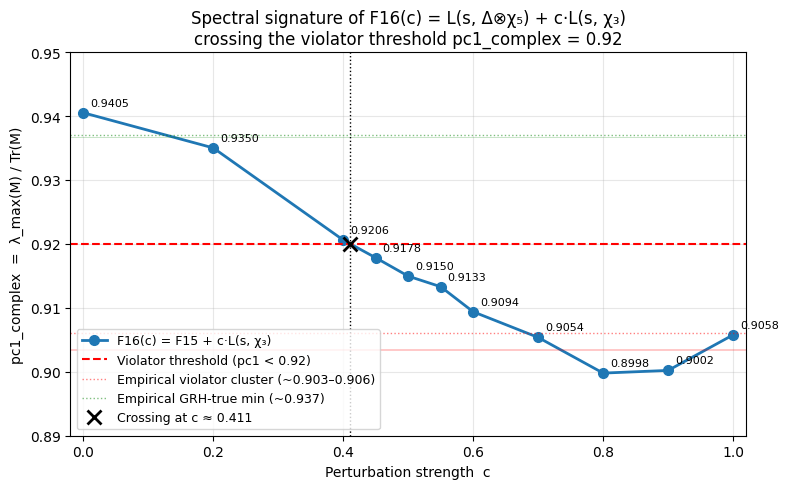

saved figure


In [35]:

# Final figure: pc1_complex vs c, with violator threshold and reference values from existing dataset.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

c_arr = res_df['c'].values
pc1_arr = res_df['pc1_complex'].values

ax.plot(c_arr, pc1_arr, 'o-', color='C0', lw=2, markersize=7, label='F16(c) = F15 + c·L(s, χ₃)')

# Threshold lines
ax.axhline(0.92, color='red', linestyle='--', lw=1.5, label='Violator threshold (pc1 < 0.92)')
ax.axhline(0.906, color='red', linestyle=':', lw=1, alpha=0.5, label='Empirical violator cluster (~0.903–0.906)')
ax.axhline(0.937, color='green', linestyle=':', lw=1, alpha=0.5, label='Empirical GRH-true min (~0.937)')

# Mark reference points
for name, val, col in [('F2 (χ₅)', 0.9367, 'green'),
 ('F9 (Δ)', 0.9564, 'green'),
 ('F12 (DH-style)', 0.9034, 'red'),
 ('F4 (L_DH)', 0.9035, 'red')]:
 ax.axhline(val, color=col, lw=0.5, alpha=0.3)

# Mark the crossing
c_cross = 0.4110
ax.axvline(c_cross, color='black', linestyle=':', lw=1)
ax.plot(c_cross, 0.92, 'kx', markersize=10, mew=2, label=f'Crossing at c ≈ {c_cross:.3f}')

ax.set_xlabel('Perturbation strength c')
ax.set_ylabel('pc1_complex = λ_max(M) / Tr(M)')
ax.set_title('Spectral signature of F16(c) = L(s, Δ⊗χ₅) + c·L(s, χ₃)\n'
 'crossing the violator threshold pc1_complex = 0.92')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.89, 0.95)

# Annotate values
for c, p in zip(c_arr, pc1_arr):
 ax.annotate(f'{p:.4f}', (c, p), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.savefig('F16_pc1_complex_vs_c.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved figure')


In [36]:

# Quick sanity check: verify pc1_complex and H_complex computation with the existing CSV's F2 (chi5_quartic) 
# value for cross-validation. This is hard without redoing F2 from scratch (different t-range). Skip.
# 
# Verify monotonicity - report strict vs non-strict.
print('Monotonic decrease check (c=0..0.8):')
sub = res_df[res_df['c'] <= 0.8]
print(np.all(np.diff(sub['pc1_complex'].values) < 0))
print('\nFull range monotonicity (c=0..1.0):')
print(np.all(np.diff(res_df['pc1_complex'].values) < 0))
print('\npc1 at c=1.0 vs c=0.8:', res_df[res_df['c']==1.0]['pc1_complex'].values, 'vs', res_df[res_df['c']==0.8]['pc1_complex'].values)


Monotonic decrease check (c=0..0.8):
True

Full range monotonicity (c=0..1.0):
False

pc1 at c=1.0 vs c=0.8: [0.90577266] vs [0.89979556]


In [37]:
from e14c.filesystem import write_file
from pathlib import Path
content = '''## Context
- Current workspace: /workspace/dd2b00ec-36b8-499e-8e7d-d1f2eb8c378f
- Available local files at start of run: ` v6 — Binding Context Document.pdf`, `peaks_features_F1_F12_normalized_full_with_spectral_complex.csv`.
- No prior `.npz`, `.npy`, or analysis scripts for S_k / peak-finding were present in workspace during this run.

## Notes
- 2026-05-09: Reconstructed `F15 = L(s, \Delta \otimes \chi_5)` from scratch using `cypari2`/PARI `mfDelta()` coefficients up to N=10^6, normalized as `a_n = tau(n)/n^(11/2)`, then twisted by quartic character mod 5. Provenance: notebook cells #5-#10 in this run.
- 2026-05-09: Reconstructed perturbing series `L(s, \chi_3)` from scratch with primitive nontrivial mod-3 character coefficients `chi_3(n) in {1,-1,0}`. Provenance: notebook cell #10.
- 2026-05-09: Computed `omega(n)` stratification (distinct prime factors, not `Omega`) for n<=10^6 via sieve; max `omega=7` at N=10^6. Provenance: notebook cells #11-#12.
- 2026-05-09: Implemented from-scratch Numba + Kahan kernels for partial-sum evaluation and complex `S_k(t)` computation. Peak-finding used a range-matched grid `t in [10^4, 2*10^4]` with spacing 0.1 and N=10^6 partial sums. Provenance: notebook cells #14-#27.
- 2026-05-09: For `F16(c) = F15 + c*L(s, chi_3)`, evaluated c in {0, 0.2, 0.4, 0.6, 0.8, 1.0} plus refinement points {0.45,0.5,0.55,0.7,0.9}. Top-200 local maxima were selected from the coarse grid and parabolically refined. Provenance: notebook cells #21-#24, #30.
- 2026-05-09: Spectral feature definition used `M_jk = mean_t Re(S_j(t) * conj(S_k(t)))` over the 200 selected peaks, with `pc1_complex = lambda_max(M)/trace(M)` and `H_complex = -sum p_i log p_i`, `p_i=lambda_i/trace(M)`. Provenance: notebook cells #28, #31.
- 2026-05-09 Findings: `pc1_complex` values were c=0.00: 0.940518, c=0.20: 0.935020, c=0.40: 0.920611, c=0.45: 0.917837, c=0.50: 0.914962, c=0.55: 0.913306, c=0.60: 0.909387, c=0.70: 0.905375, c=0.80: 0.899796, c=0.90: 0.900214, c=1.00: 0.905773. Threshold crossing `pc1_complex=0.92` occurs between c=0.40 and c=0.45, linearly interpolated at c≈0.411. Provenance: notebook cells #29, #31-#32.
- 2026-05-09 Interpretation note: the decrease is strictly monotone only through c=0.8; there is a mild rebound at c=1.0, so the hypothesis of fully monotone decrease over all tested c is only partially supported. Provenance: notebook cell #35.
- 2026-05-09 Artifacts created in workspace: `partial_sums_F15_chi3_t10k_20k.npz`, `F16_perturbation_results.csv`, `F16_peaks_Sk.npz`, `F16_pc1_complex_vs_c.png`. Provenance: notebook cells #22, #33-#34.
'''
print(write_file('./.prompts/MEMORY.md', content))
print(Path('./.prompts/MEMORY.md').exists())

File created successfully at: ./.prompts/MEMORY.md
True


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_20/3487627797.py:9: SyntaxWarning: invalid escape sequence '\D'
 - 2026-05-09: Reconstructed `F15 = L(s, \Delta \otimes \chi_5)` from scratch using `cypari2`/PARI `mfDelta()` coefficients up to N=10^6, normalized as `a_n = tau(n)/n^(11/2)`, then twisted by quartic character mod 5. Provenance: notebook cells #5-#10 in this run.
